# Exploratory Data Analysis for EDA signal
Type: Breathing sensor\
Unit: percentage variation

This represents breathing expansion/contraction of chest.

**Stress effect on breathing**
| State  | Breathing        |
| ------ | ---------------- |
| Calm   | slow and deep    |
| Stress | fast and shallow |

The dataset calculates respiration using this transformation: 

$$Resp = \frac{signal}{{chan \ bit}} - 0.5 \times 100$$

chan_bit = 2^16 ..... { from WESAD dataset documentation }

Because of the −0.5 shift, the signal is centered around zero, so it naturally produces positive and negative values.

| Resp Value   | Meaning                          |
| ------------ | -------------------------------- |
| Positive (+) | chest expanding → **inhaling**   |
| Negative (−) | chest contracting → **exhaling** |
| Near 0       | neutral point between breaths    |

Breathing has two phases:

1. Inhalation → chest expands
2. Exhalation → chest contracts

The signal behaves like a wave.
```
Respiration signal

   ↑ chest expansion (inhale)
 +1 |      /\        /\
    |     /  \      /  \
  0 |----/----\----/----\-----
    |   /      \  /      \
 -1 |  /        \/        \
   ↓ chest contraction (exhale)

              time →
```
> each value in the `Resp` column is simply the instantaneous breathing signal at that moment.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../../Dataset/S2_chest_data.csv")
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return "stressed"
    elif label in nStr:
        return "not stressed"
    else:
        return "unknown"

df["target"] = df["Label"].apply(apply_target)

df.head(2)

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label,target
214583,0.8914,-0.1102,-0.2576,0.030945,-0.003708,5.710983,29.083618,1.191711,1,not stressed
214584,0.8926,-0.1086,-0.2544,0.033646,-0.014145,5.719376,29.122437,1.139832,1,not stressed


# EDA starts from here

In [8]:
df["Resp"].describe()

count    2.022299e+06
mean     5.047145e-02
std      2.229207e+00
min     -2.019653e+01
25%     -1.321411e+00
50%     -1.724243e-01
75%      1.438904e+00
max      1.927032e+01
Name: Resp, dtype: float64

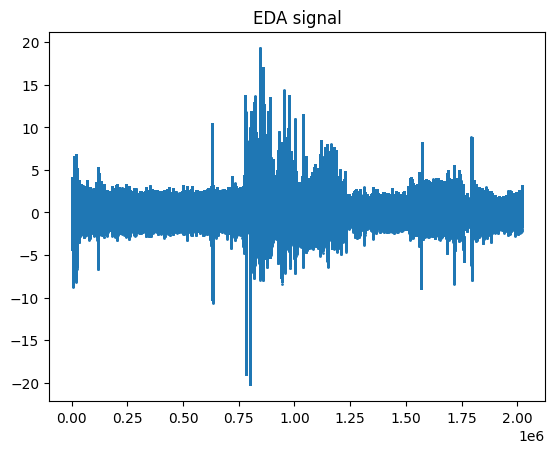

In [9]:
plt.scatter(range(len(df)), df["Resp"], s=1)
plt.title("EDA signal")
plt.show()

In [10]:
str_EDA = df[df["target"] == "stressed"]
nStr_EDA = df[df["target"] == "not stressed"]

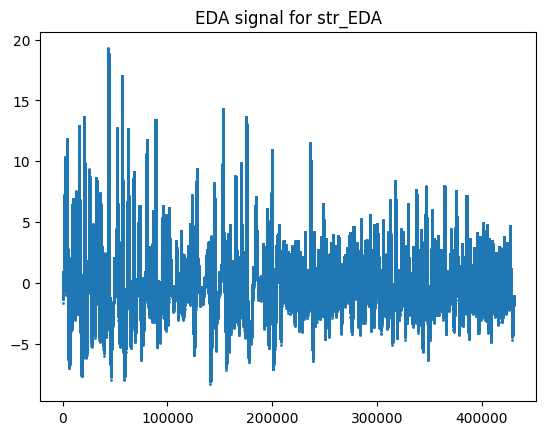

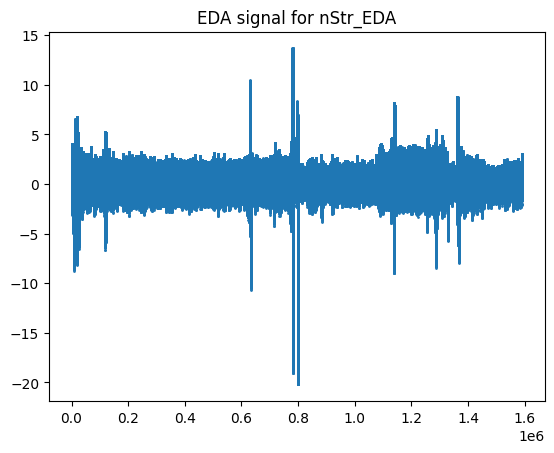

In [12]:
plt.scatter(range(len(str_EDA)), str_EDA["Resp"], s=1)
plt.title("EDA signal for str_EDA")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["Resp"], s=1)
plt.title("EDA signal for nStr_EDA")
plt.show()

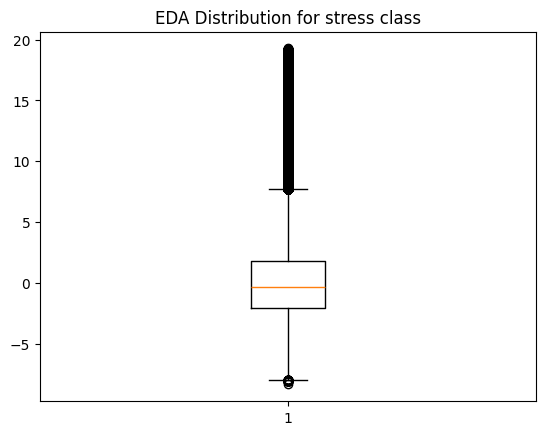

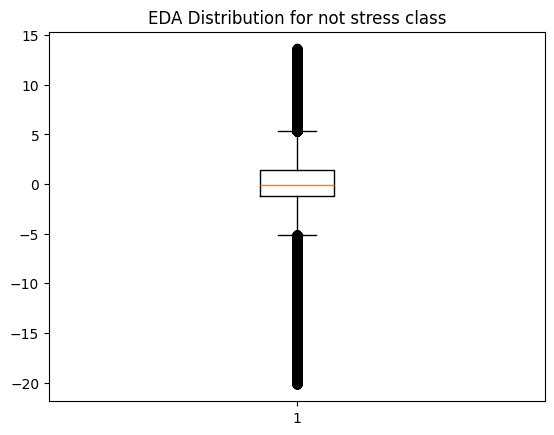

In [14]:
plt.boxplot(str_EDA["Resp"])
plt.title("EDA Distribution for stress class")
plt.show()

plt.boxplot(nStr_EDA["Resp"])
plt.title("EDA Distribution for not stress class")
plt.show()

### Removing the outlier of stress class

C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_22180\4155128172.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = str_EDA[(df["Resp"] >= lower) & (str_EDA["Resp"] <= upper)]


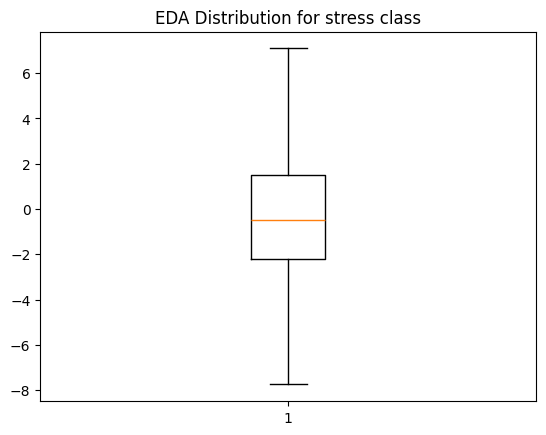

In [17]:
while True:
    Q1 = str_EDA["Resp"].quantile(0.25)
    Q3 = str_EDA["Resp"].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    new_df = str_EDA[(df["Resp"] >= lower) & (str_EDA["Resp"] <= upper)]

    # stop when no more rows are removed
    if len(new_df) == len(str_EDA):
        break

    str_EDA = new_df

plt.boxplot(str_EDA["Resp"])
plt.title("EDA Distribution for stress class")
plt.show()

### Removing the outlier of non stress class

C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_22180\4198016948.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["Resp"] >= lower) & (nStr_EDA["Resp"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_22180\4198016948.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["Resp"] >= lower) & (nStr_EDA["Resp"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_22180\4198016948.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["Resp"] >= lower) & (nStr_EDA["Resp"] <= upper)]


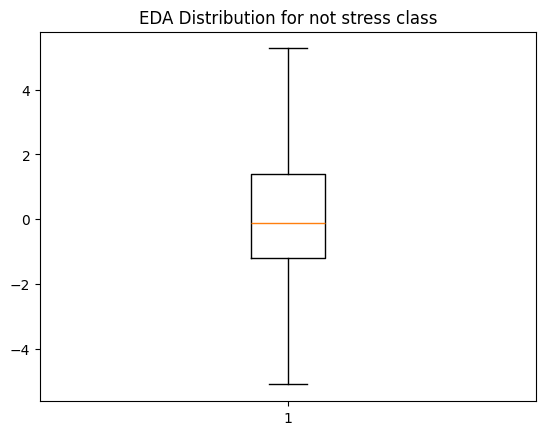

In [16]:
while True:
    Q1 = nStr_EDA["Resp"].quantile(0.25)
    Q3 = nStr_EDA["Resp"].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    new_df = nStr_EDA[(df["Resp"] >= lower) & (nStr_EDA["Resp"] <= upper)]

    # stop when no more rows are removed
    if len(new_df) == len(nStr_EDA):
        break

    nStr_EDA = new_df

plt.boxplot(nStr_EDA["Resp"])
plt.title("EDA Distribution for not stress class")
plt.show()

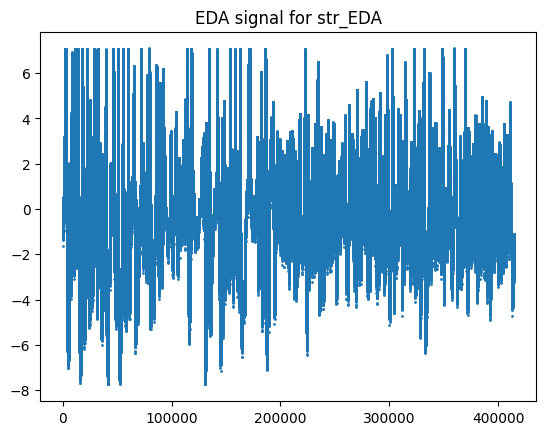

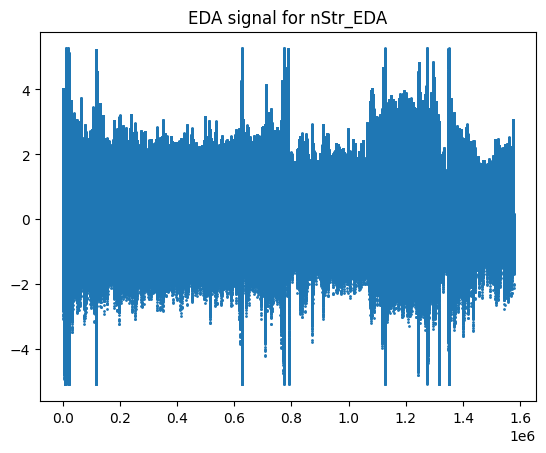

In [18]:
plt.scatter(range(len(str_EDA)), str_EDA["Resp"], s=1)
plt.title("EDA signal for str_EDA")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["Resp"], s=1)
plt.title("EDA signal for nStr_EDA")
plt.show()

In [19]:
str_EDA["Resp"].describe()

count    414334.000000
mean         -0.316579
std           2.747541
min          -7.743835
25%          -2.186584
50%          -0.477600
75%           1.521301
max           7.083130
Name: Resp, dtype: float64

In [20]:
nStr_EDA["Resp"].describe()

count    1.576659e+06
mean     7.575125e-02
std      1.556675e+00
min     -5.104065e+00
25%     -1.213074e+00
50%     -1.205444e-01
75%      1.380920e+00
max      5.271912e+00
Name: Resp, dtype: float64